**Libraries**

In [105]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any, NamedTuple
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

**Notebook's General Variables**

In [106]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG_smoothing'
SAVE_THINGS: bool = False

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = False

**Mask and Data Specifics**

In [107]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_testing_PSF_newSGmodel"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "detected"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = False

**Analysis Methods**

In [108]:
class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float


def get_candidates(
    log: Log,
    thresh: int | float,
) -> tuple[Candidate, ...]:
    """
    Extracts the candidates from the IROS log with a
    significance lower than the input threshold.
    """
    _upto: int = np.argwhere(
        np.array(log.log['snr']) < thresh
    )[0, 0]

    candidates: tuple[Candidate, ...] = tuple(
        Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
            log.log['shift_x'][:_upto],
            log.log['shift_y'][:_upto],
            log.log['fluence'][:_upto],
            log.log['snr'][:_upto],
        )
    )
    print(
        f"Number of candidates with SNR > {thresh}: {len(candidates)}\n"
        f"Last: {log.log['ID'][_upto - 1]} (snr = {log.log['snr'][_upto - 1]:.2f})\n"
        f"Following: {log.log['ID'][_upto]} (snr = {log.log['snr'][_upto]:.2f})\n"
    )
    return candidates


def retrieve_detector(
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Generates detector image from retrieved candidates."""
    detector = np.zeros(camera.shape_detector)
    for (sx, sy, f, _) in candidates:
        sg = model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        )
        detector += (f * sg)
    return detector


def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    sources, thetas_x, thetas_y = [], [], []
    for sourceID in log.log['ID']:
        if sourceID in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE!!!
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetax, thetay = map(lambda x: shift2angle(camera, x), (sx, sy))
            sources.append(sourceID)
            thetas_x.append(thetax)
            thetas_y.append(thetay)
        else:
            print(f'Source {sourceID.upper()} not in catalogue...')
            sources.append(sourceID)
            thetas_x.append(np.nan)
            thetas_y.append(np.nan)
        
    df = pd.DataFrame(
        {'ID': sources, 'THETAX': thetas_x, 'THETAY': thetas_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    theta_x, theta_y = map(
        np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - theta_x),
        60 * np.abs(np.array(log.log['angle_y']) - theta_y),
    )
    return res_x, res_y

In [109]:
def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """
    Collapses input 2D array by adding the elements along
    one axis, for both the (x, y) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along rows (x-axis view)
            - collapsed array along cols (y-axis view)
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along y has length `m`, while the collapsed
          array along x has length `n`.
    """
    return np.sum(arr, axis=0), np.sum(arr, axis=1)


def config_snrlim(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures significance histograms values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf significance limit.
        stop (int | float): Sup significance limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max else None)
    return slice_bins, slice_hist

In [110]:
def data_DF(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    def dict2df(data: dict[str, dict[str, Any]]) -> pd.DataFrame:
        """
        Converts input data dict in Dataframe.
        """
        df = pd.DataFrame({
            (cam, param): values
            for cam, cam_data in data.items() 
            for param, values in cam_data.items()
        })
        return df
    
    pxdim_y, pxdim_x = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    dtheta_y, dtheta_x = map(
        lambda x: np.rad2deg(np.arctan(x / camera.specs.mask_detector_distance)) * 60,
        (pxdim_y, pxdim_x),
    )    
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log=log,
        catalogue=catalogue,
        sdl=sdl,
        camera=camera,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'SNR': log.log['snr'],
            'SHIFT_X [mm]': log.log['shift_x'],
            'SHIFT_Y [mm]': log.log['shift_y'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
        }
    }
    print(
        f"Pixel angular resolution at upscaling (x, y): {camera.upscale_f.x}, {camera.upscale_f.y}\n"
        f"  - fine direction: {dtheta_x:.4f} arcmin\n"
        f"  - coarse direction: {dtheta_y:.4f} arcmin\n"
    )
    return dict2df(dmap)


def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)


def Gaussian(x: NDArray, x0: float = 0.0, sigma: float = 1.0) -> NDArray:
    """Returns a 1D Gaussian distribution centered around `x0` and with std `sigma`."""
    return (
        1.0 / np.sqrt(2 * np.pi * np.square(sigma)) * np.exp(-np.square(x - x0) / (2 * np.square(sigma)))
    )

**Load Mask and Data**

In [ ]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
ASPECT: float = (wfm.specs.mask_deltay / UPS_Y) / (wfm.specs.mask_deltax / UPS_X)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [112]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
#res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [113]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
#res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [114]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


**Analysis for LEM-X Camera A**

In [115]:
assert ANALYSIS_CAM1A

In [116]:
# sources data + angular coords residues plot
data_DF(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

Pixel angular resolution at upscaling (x, y): 5, 1
  - fine direction: 0.8465 arcmin
  - coarse direction: 8.4653 arcmin



CAM1A                                                         \
            ID         SNR SHIFT_X [mm] SHIFT_Y [mm] DthetaX [arcmin]   
0        scox1  728.386202    43.909516    78.044804         0.001836   
1        gx5-1   70.448367    13.529472   -12.428729         0.005260   
2      gx349+2   53.946563   -28.164881    28.768286         0.075654   
3       gx17+2   47.079300    53.587883   -27.427128         0.038942   
4        gx9+1   42.670333    29.852586   -13.297258         0.016656   
5      gx340+0   31.965476   -64.629685    39.208140         0.095119   
6  groj1655-40   27.779262   -41.782813    36.334306         0.005061   
7    x1820-303   23.544529    -6.283126   -28.915102         0.248010   
8       gx13+1   23.231802    41.887219   -24.933139         0.081216   
9        gx3+1   22.317533     8.416092    -2.620318         0.081019   

                    
  DthetaY [arcmin]  
0         0.014896  
1         1.390504  
2         0.945183  
3         3.867831  
4         1.300299  
5         1.748007  
6         4.389413  
7         6.126434  
8         3.120822  
9        12.971318

In [117]:
SMOOTHING_THRESHOLD: int | float = 25.0

candidates: tuple[Candidate, ...] = get_candidates(log_camA, SMOOTHING_THRESHOLD)

Number of candidates with SNR > 25.0: 7
Last: groj1655-40 (snr = 27.78)
Following: x1820-303 (snr = 23.54)



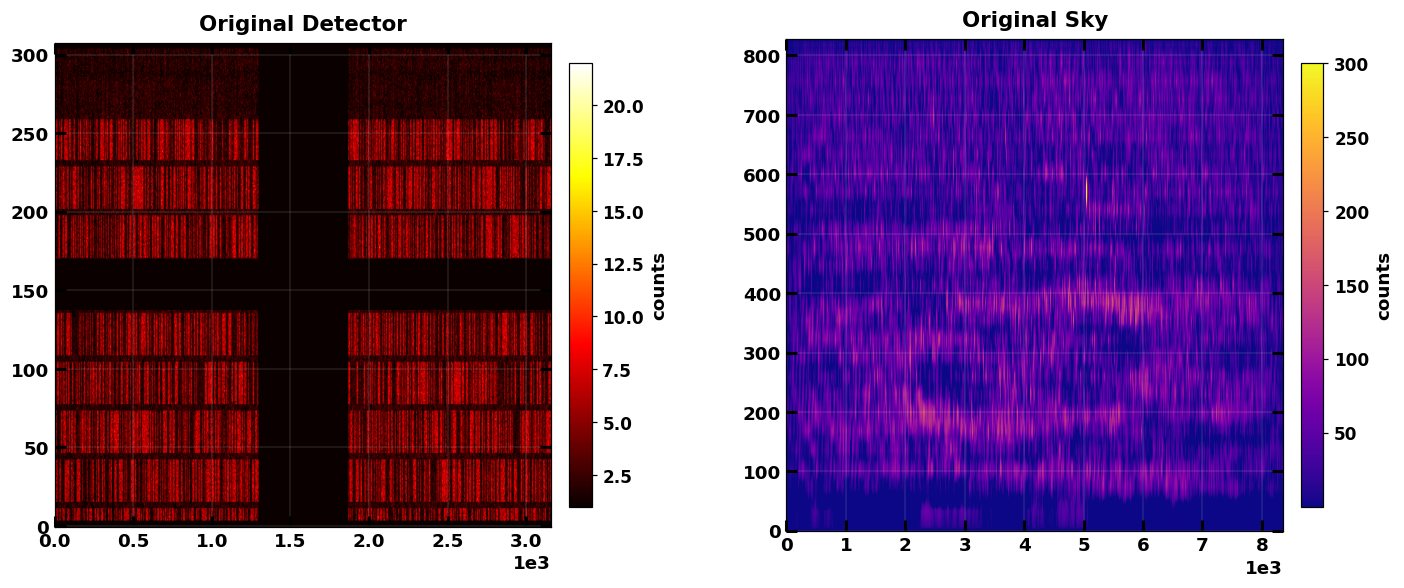

In [ ]:
detector = count(wfm, sdlA.DLdata)[0]


EXP = 0.5

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title='Original Detector',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(true_sky_camA, EXP),
            title='Original Sky',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 3e2,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

**Analysis for LEM-X Camera B**

In [118]:
assert ANALYSIS_CAM1B

AssertionError: 